# 🎓 Independent Component Analysis (ICA)
## A Comprehensive Interactive Tutorial

---

## 📚 Overview

This notebook provides a **detailed, from-basics introduction** to Independent Component Analysis (ICA), covering:

- **Part I:** Foundational concepts (Central Limit Theorem, independence vs. correlation)
- **Part II:** ICA algorithm from scratch (centering, whitening, rotation)
- **Part III:** Interactive kurtosis maximization
- **Part IV:** Fixed-point iteration algorithm
- **Part V:** Using sklearn's FastICA
- **Part VI:** Geometric interpretation
- **Part VII-VIII:** Real-world applications (audio, images)
- **Part IX:** Evaluation metrics and comparison with PCA
- **Part X:** Advanced topics
- **Part XI:** Summary and key takeaways

### 🎯 Learning Objectives

By the end of this notebook, you will:

1. ✅ Understand **why ICA exists** and how it differs from PCA
2. ✅ Master the mathematical foundations (independence, non-Gaussianity, mixing model)
3. ✅ Implement ICA **from scratch** using kurtosis maximization
4. ✅ Understand the **fixed-point algorithm** and contrast functions
5. ✅ Apply ICA to **real-world problems** (audio separation, image unmixing)
6. ✅ Evaluate separation quality with **performance metrics**
7. ✅ Know when to use ICA vs. PCA or other methods

---

**Prerequisites:** Basic linear algebra, probability, Python programming

**Estimated time:** 2-3 hours

---

# 🔧 Setup and Imports

First, we import all necessary libraries and configure plotting styles for consistency.

In [3]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Statistical tools
from scipy.stats import kurtosis, norm

# Machine learning
from sklearn.decomposition import FastICA, PCA

# Interactive widgets
from ipywidgets import interact, IntSlider
import matplotlib.animation as animation
from IPython.display import HTML

# For reproducibility
np.random.seed(42)

# Plotting style
plt.style.use("seaborn-v0_8")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.dpi"] = 100

print("✅ All libraries imported successfully!")
print(f"📦 NumPy version: {np.__version__}")
print(f"🎨 Matplotlib backend: {plt.get_backend()}")
print("")
print("🎯 Ready to explore Independent Component Analysis!")

✅ All libraries imported successfully!
📦 NumPy version: 2.3.5
🎨 Matplotlib backend: module://matplotlib_inline.backend_inline

🎯 Ready to explore Independent Component Analysis!


---

# Part I: Foundations - Why ICA Exists?

Before diving into the ICA algorithm, we need to understand **why** independence matters and **how** mixing destroys it.

## 1.1 The Central Limit Theorem and ICA

### 🔬 The Problem

When independent non-Gaussian sources are **mixed together**, their sum tends toward a **Gaussian distribution** (Central Limit Theorem). This makes it hard to separate them!

### 📊 Experiment

We'll generate samples from different distributions and observe what happens when we sum increasing numbers of independent variables.

**Mathematical formulation:**

Let $X_1, X_2, \ldots, X_k$ be i.i.d. random variables from distribution $F$.

Define normalized sum: $S_k = \frac{\sum_{i=1}^{k} X_i}{\sqrt{k}}$

**Central Limit Theorem:** As $k \to \infty$, $S_k \xrightarrow{d} \mathcal{N}(\mu, \sigma^2)$

This happens **regardless** of the original distribution $F$!

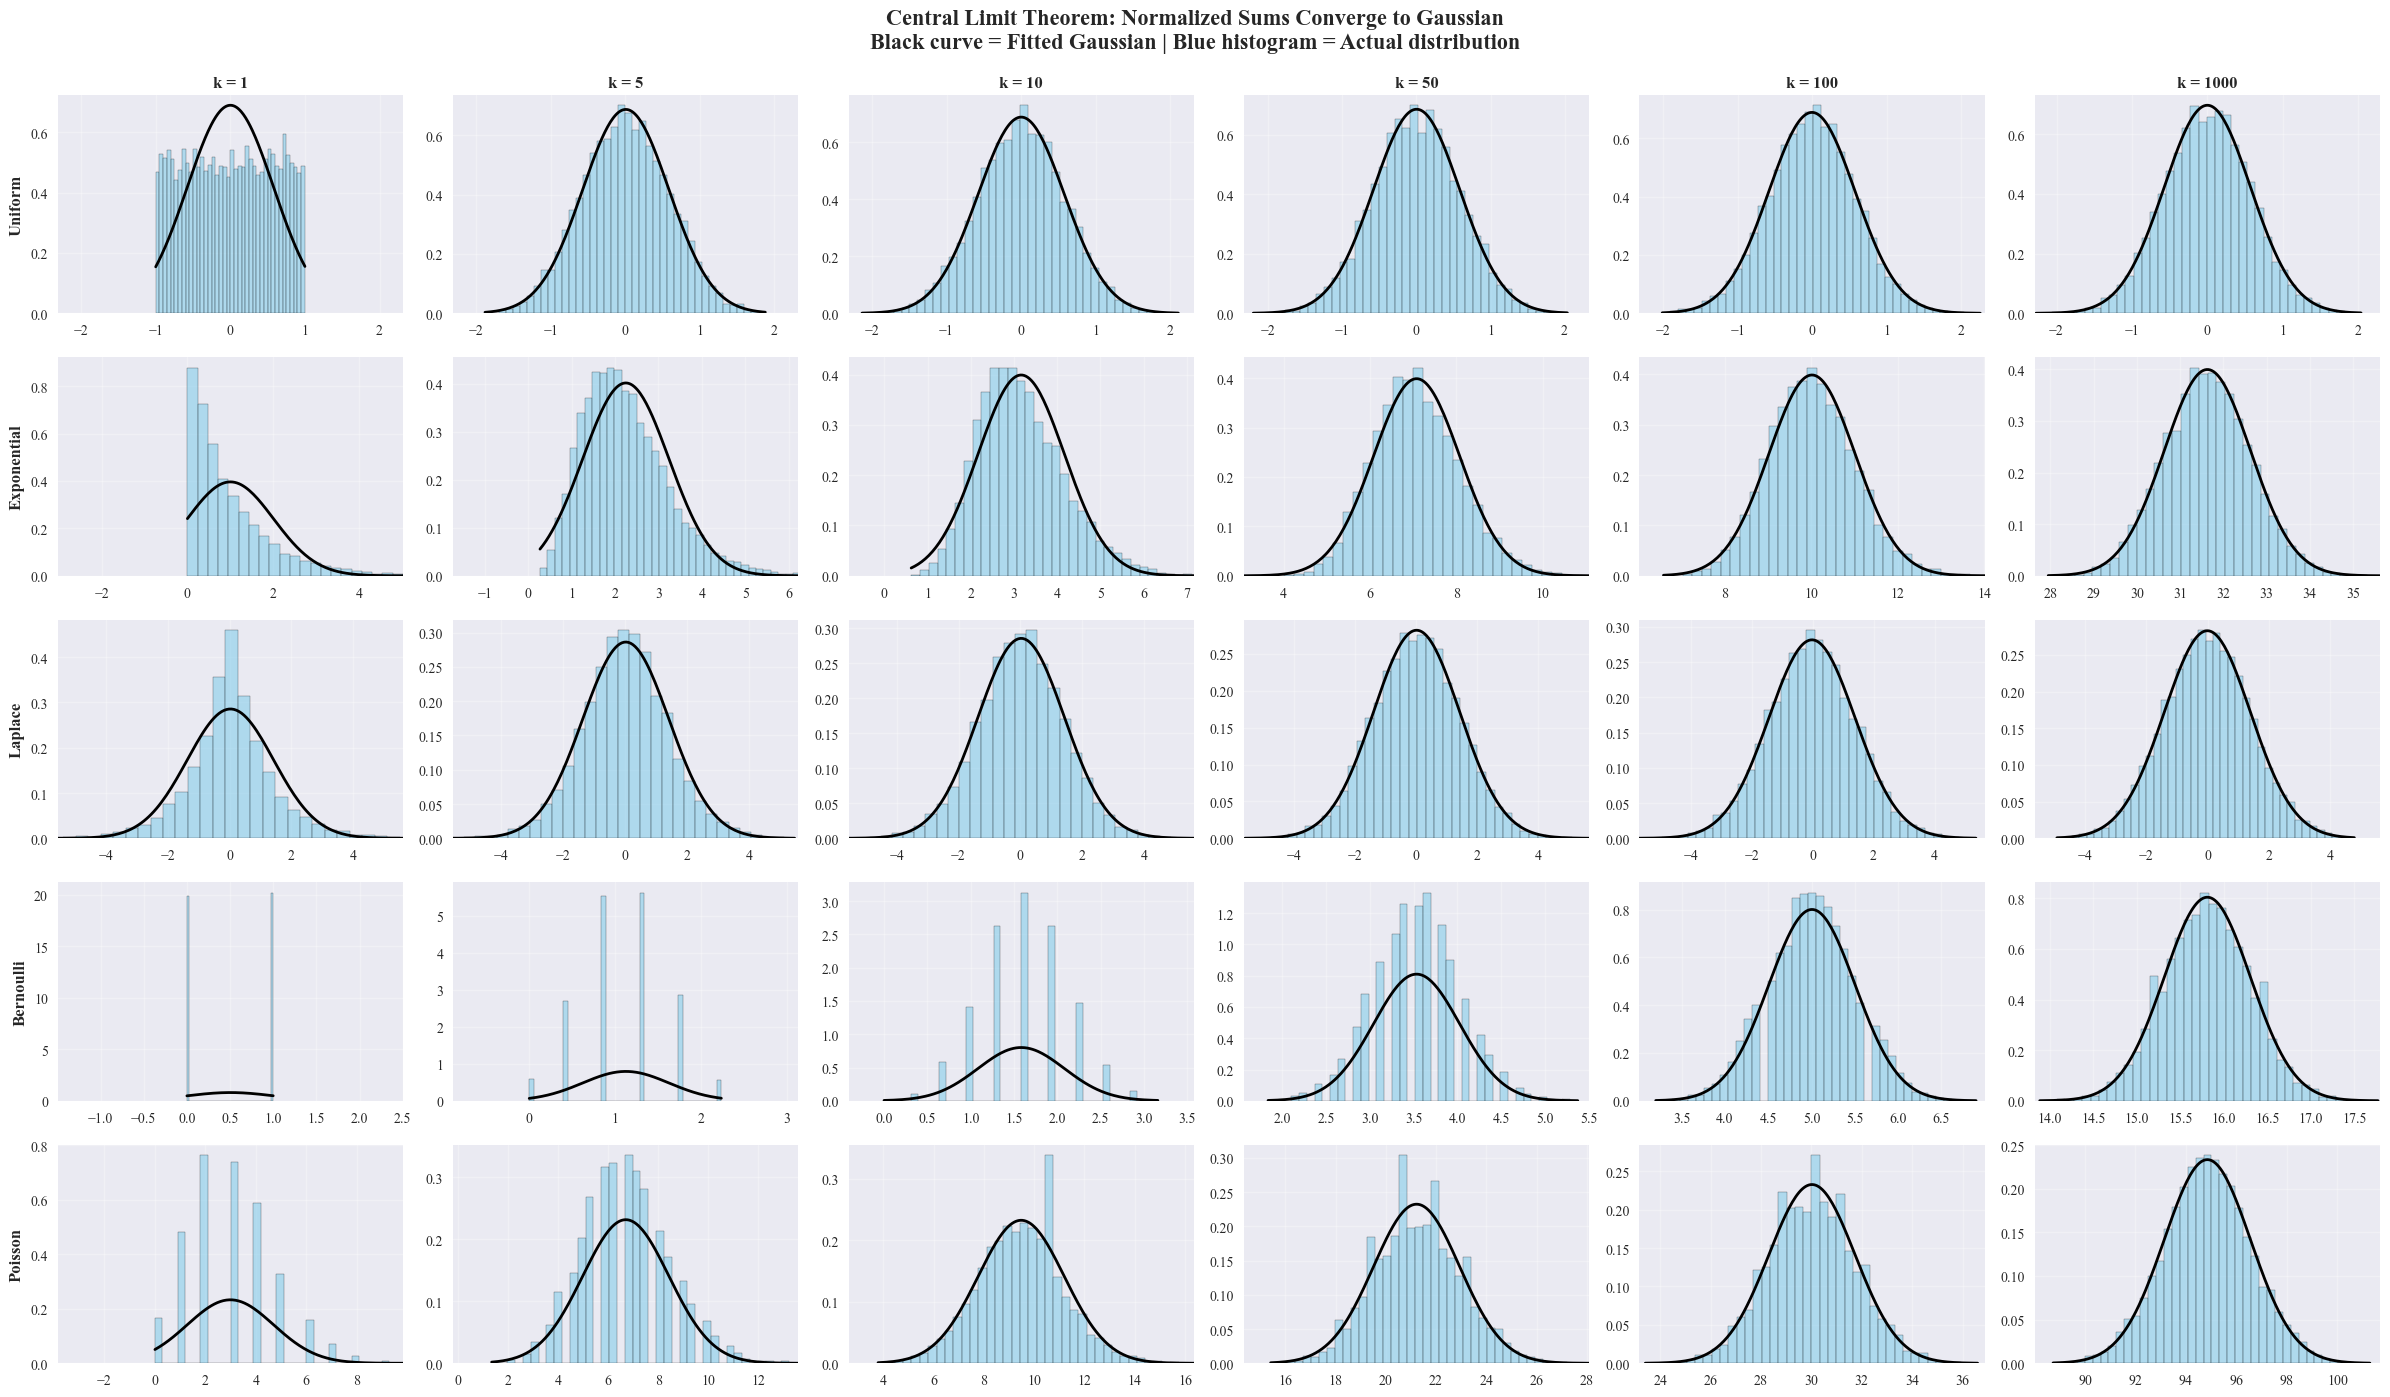


📈 Observation: As k increases, ALL distributions converge to Gaussian!
🎯 Implication for ICA: Mixtures are more Gaussian than sources.
💡 Strategy: Find directions that are LEAST Gaussian to recover sources.


In [4]:
def generate_data(dist, n_samples, n_vars):
    """Generate i.i.d. samples from different distributions.
    
    Parameters
    ----------
    dist : str
        Distribution type: 'uniform', 'exponential', 'laplace', 'bernoulli', 'poisson'
    n_samples : int
        Number of samples to generate
    n_vars : int
        Number of independent variables
    
    Returns
    -------
    X : ndarray, shape (n_samples, n_vars)
        Generated samples
    """
    if dist == "uniform":
        return np.random.uniform(-1, 1, (n_samples, n_vars))
    elif dist == "exponential":
        return np.random.exponential(scale=1.0, size=(n_samples, n_vars))
    elif dist == "laplace":
        return np.random.laplace(0, 1, (n_samples, n_vars))
    elif dist == "bernoulli":
        return np.random.binomial(1, 0.5, (n_samples, n_vars))
    elif dist == "poisson":
        return np.random.poisson(lam=3.0, size=(n_samples, n_vars))
    else:
        raise ValueError(f"Unknown distribution: {dist}")

# Generate Central Limit Theorem visualization
n_samples = 10000
k_values = [1, 5, 10, 50, 100, 1000]
distributions = ["uniform", "exponential", "laplace", "bernoulli", "poisson"]

fig, axes = plt.subplots(len(distributions), len(k_values),
                         figsize=(24, 14), sharex=False, sharey=False)

for row, dist in enumerate(distributions):
    X = generate_data(dist, n_samples, max(k_values))
    for col, k in enumerate(k_values):
        ax = axes[row, col]
        
        # Normalized sum
        sums = X[:, :k].sum(axis=1) / np.sqrt(k)

        # Histogram
        ax.hist(sums, bins=40, density=True, alpha=0.6,
                color="skyblue", edgecolor="black")

        # Gaussian overlay
        mu, sigma = np.mean(sums), np.std(sums)
        x_vals = np.linspace(np.min(sums), np.max(sums), 200)
        ax.plot(x_vals, norm.pdf(x_vals, mu, sigma), 'k', lw=2)

        # Titles/labels
        if col == 0:
            ax.set_ylabel(dist.capitalize(), fontsize=12, fontweight='bold')
        if row == 0:
            ax.set_title(f"k = {k}", fontsize=12, fontweight='bold')
        
        ax.set_xlim([mu - 4*sigma, mu + 4*sigma])
        ax.grid(True, alpha=0.3)

fig.suptitle("Central Limit Theorem: Normalized Sums Converge to Gaussian\n" +
             "Black curve = Fitted Gaussian | Blue histogram = Actual distribution",
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n📈 Observation: As k increases, ALL distributions converge to Gaussian!")
print("🎯 Implication for ICA: Mixtures are more Gaussian than sources.")
print("💡 Strategy: Find directions that are LEAST Gaussian to recover sources.")

### 🎯 Key Learning #1: Central Limit Theorem

**What we observed:**
- For **small** $k$, distributions retain their original shape (uniform stays flat, exponential stays skewed)
- As $k$ **increases**, ALL distributions converge to Gaussian, regardless of the original shape
- By $k=1000$, even highly non-Gaussian distributions (Bernoulli, Poisson) are nearly Gaussian

**Why this matters for ICA:**
1. When independent sources are **mixed** (i.e., summed with different weights), the mixture is **more Gaussian** than the sources
2. Gaussian distributions have **maximum entropy** among all distributions with the same variance
3. To separate sources, ICA looks for projections that are **maximally non-Gaussian**

✅ **Takeaway:** ICA exploits the fact that **linear mixtures are closer to Gaussian** than the original independent sources.

---

## 1.2 Independence vs. Correlation

### 🤔 What's the Difference?

Many students confuse **uncorrelated** with **independent**. Let's clarify:

**Correlation** measures **linear** dependence:
$$\rho(X, Y) = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y} = \frac{\mathbb{E}[(X - \mu_X)(Y - \mu_Y)]}{\sigma_X \sigma_Y}$$

**Independence** means **no dependence** of any kind:
$$p(x, y) = p(x) \cdot p(y) \quad \forall x, y$$

**Mutual Information** measures general dependence:
$$I(X; Y) = \sum_{x, y} p(x, y) \log \frac{p(x, y)}{p(x)p(y)}$$

### 📊 Three Examples

We'll demonstrate three cases:
1. **Independent sources**: $\rho \approx 0$, $I \approx 0$
2. **Linearly dependent sources**: $\rho \neq 0$, $I > 0$
3. **Uncorrelated but dependent**: $\rho = 0$, $I > 0$ (e.g., $Y = X^2$)

In [ ]:
# --- From-scratch implementations ---

def correlation(x, y):
    """Compute Pearson correlation from scratch."""
    n = len(x)
    mean_x, mean_y = sum(x)/n, sum(y)/n
    num = sum((xi-mean_x)*(yi-mean_y) for xi, yi in zip(x,y))
    den = math.sqrt(sum((xi-mean_x)**2 for xi in x) * sum((yi-mean_y)**2 for yi in y))
    return num/den if den!=0 else 0

def mutual_information(x, y, bins=30):
    """Estimate mutual information using histogram method."""
    n = len(x)
    # Bin edges
    x_bins = np.linspace(min(x), max(x), bins+1)
    y_bins = np.linspace(min(y), max(y), bins+1)
    # Digitize samples
    x_d = np.digitize(x, x_bins) - 1
    y_d = np.digitize(y, y_bins) - 1
    # Joint and marginals
    joint_counts = Counter(zip(x_d, y_d))
    px, py = Counter(x_d), Counter(y_d)
    mi = 0.0
    for (xi, yi), c in joint_counts.items():
        p_xy = c/n
        p_x, p_y = px[xi]/n, py[yi]/n
        mi += p_xy * math.log((p_xy/(p_x*p_y+1e-12))+1e-12, 2)  # log base-2
    return max(0, mi)  # MI cannot be negative

# --- Example 1: Independent sources ---
np.random.seed(0)
n_samples = 2000
s1 = np.random.normal(0, 1, n_samples)      # Gaussian
s2 = np.random.laplace(0, 1, n_samples)     # Laplace (non-Gaussian)

rho_indep = correlation(s1.tolist(), s2.tolist())
mi_indep = mutual_information(s1.tolist(), s2.tolist(), bins=30)

# --- Example 2: Linearly correlated sources ---
s3 = np.random.normal(0, 1, n_samples)
s4 = 0.8 * s3 + 0.2 * np.random.normal(0, 1, n_samples)

rho_corr = correlation(s3.tolist(), s4.tolist())
mi_corr = mutual_information(s3.tolist(), s4.tolist(), bins=30)

# --- Example 3: Uncorrelated but dependent (X, X²) ---
s5 = np.random.normal(0, 1, n_samples)
s6 = s5**2

rho_dep = correlation(s5.tolist(), s6.tolist())
mi_dep = mutual_information(s5.tolist(), s6.tolist(), bins=30)

# --- Visualization ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Example 1: Independent
axes[0, 0].plot(s1, color="blue", alpha=0.7, label="s1 (Gaussian)")
axes[0, 0].plot(s2, color="red", alpha=0.7, label="s2 (Laplace)")
axes[0, 0].set_title("Independent Sources", fontweight='bold')
axes[0, 0].legend()
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("Amplitude")

axes[1, 0].scatter(s1, s2, alpha=0.3, color="purple", edgecolor="k", s=10)
axes[1, 0].set_title(f"ρ = {rho_indep:.3f}, MI = {mi_indep:.3f} bits", fontweight='bold')
axes[1, 0].set_xlabel("s1")
axes[1, 0].set_ylabel("s2")
axes[1, 0].grid(True, alpha=0.3)

# Example 2: Correlated
axes[0, 1].plot(s3, color="blue", alpha=0.7, label="s3")
axes[0, 1].plot(s4, color="orange", alpha=0.7, label="s4 = 0.8*s3 + noise")
axes[0, 1].set_title("Correlated Sources", fontweight='bold')
axes[0, 1].legend()
axes[0, 1].set_xlabel("Time")

axes[1, 1].scatter(s3, s4, alpha=0.3, color="orange", edgecolor="k", s=10)
axes[1, 1].set_title(f"ρ = {rho_corr:.3f}, MI = {mi_corr:.3f} bits", fontweight='bold')
axes[1, 1].set_xlabel("s3")
axes[1, 1].set_ylabel("s4")
axes[1, 1].grid(True, alpha=0.3)

# Example 3: Uncorrelated but dependent
axes[0, 2].plot(s5, color="blue", alpha=0.7, label="s5")
axes[0, 2].plot(s6, color="green", alpha=0.7, label="s6 = s5²")
axes[0, 2].set_title("Uncorrelated but Dependent", fontweight='bold')
axes[0, 2].legend()
axes[0, 2].set_xlabel("Time")

axes[1, 2].scatter(s5, s6, alpha=0.3, color="green", edgecolor="k", s=10)
axes[1, 2].set_title(f"ρ = {rho_dep:.3f}, MI = {mi_dep:.3f} bits", fontweight='bold')
axes[1, 2].set_xlabel("s5")
axes[1, 2].set_ylabel("s6 = s5²")
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(f"\n1. Independent sources:     ρ = {rho_indep:6.3f}  |  MI = {mi_indep:.3f} bits")
print(f"2. Correlated sources:      ρ = {rho_corr:6.3f}  |  MI = {mi_corr:.3f} bits")
print(f"3. Uncorrelated but dependent: ρ = {rho_dep:6.3f}  |  MI = {mi_dep:.3f} bits")
print("\n" + "="*80)

### 🎯 Key Learning #2: Independence vs. Correlation

**What we observed:**

| Example | Relationship | Correlation (ρ) | Mutual Info (MI) |
|---------|--------------|-----------------|------------------|
| Independent | No dependence | ≈ 0 | ≈ 0 |
| Correlated | Linear dependence | ≠ 0 (high) | > 0 (high) |
| X, X² | Nonlinear dependence | ≈ 0 | > 0 (high) |

**Key insights:**
1. **Correlation** only detects **linear** relationships
2. **Independence** implies uncorrelated, but uncorrelated ≠ independent
3. **Mutual Information** captures any kind of dependence (linear or nonlinear)
4. **PCA** removes correlation (decorrelation), but **ICA** removes all dependence (independence)

✅ **Takeaway:** ICA seeks components with **minimum mutual information**, not just zero correlation.

---

## 1.3 The ICA Problem Statement

### 📝 Mathematical Model

**Blind Source Separation (BSS):**

Assume we observe $n$ mixtures of $n$ independent sources:

$$\mathbf{x}(t) = \mathbf{A} \mathbf{s}(t)$$

where:
- $\mathbf{s}(t) = [s_1(t), s_2(t), \ldots, s_n(t)]^T$ — **independent sources** (unknown)
- $\mathbf{A} \in \mathbb{R}^{n \times n}$ — **mixing matrix** (unknown, non-singular)
- $\mathbf{x}(t) = [x_1(t), x_2(t), \ldots, x_n(t)]^T$ — **observed mixtures** (known)

**Goal:** Find the **unmixing matrix** $\mathbf{W} = \mathbf{A}^{-1}$ such that:

$$\mathbf{\hat{s}}(t) = \mathbf{W} \mathbf{x}(t) \approx \mathbf{s}(t)$$

### 🔑 Key Assumptions

ICA requires the following assumptions:

1. **Statistical independence:** Sources $s_i(t)$ are mutually independent:
   $$p(\mathbf{s}) = \prod_{i=1}^{n} p(s_i)$$

2. **Non-Gaussianity:** At most **one** source can be Gaussian. Why? Because:
   - Gaussian variables remain Gaussian under orthogonal transformations
   - Cannot distinguish between Gaussian sources using higher-order statistics

3. **Linear mixing:** No nonlinear transformations (e.g., $x \neq \sin(s)$)

4. **Instantaneous mixing:** No time delays (e.g., $x(t) \neq s(t-\tau)$)

5. **Square mixing matrix:** Number of sources = number of mixtures ($n \times n$)
   - Can be relaxed (overcomplete/undercomplete ICA)

### ⚠️ Fundamental Ambiguities

Even with perfect separation, ICA **cannot determine**:

1. **Ordering (permutation):** We don't know which recovered component corresponds to which original source
   - $\mathbf{W}\mathbf{A} = \mathbf{P}$ (permutation matrix)

2. **Scaling (sign and amplitude):** We can't determine the original amplitude or sign
   - $\mathbf{W}\mathbf{A} = \mathbf{D}$ (diagonal scaling matrix)

**Why?** Because if $\mathbf{x} = \mathbf{A}\mathbf{s}$, then $\mathbf{x} = (\mathbf{A}\mathbf{D}^{-1})(\mathbf{D}\mathbf{s})$ gives the same observations.

✅ **Takeaway:** ICA recovers independent components **up to permutation and scaling**.

---

# Part II: ICA Algorithm From Scratch

Now we'll implement ICA step-by-step using synthetic signals. This helps build intuition before using library implementations.

## 2.1 Generate Synthetic Signals

We create three **non-Gaussian** independent sources and mix them artificially.

In [ ]:
np.random.seed(42)
n_samples = 2000
time = np.linspace(0, 8, n_samples)

# Three independent sources with different characteristics
s1 = np.sin(2 * time)                      # Sine wave (periodic)
s2 = np.sign(np.sin(3 * time))             # Square wave (discrete-like)
s3 = np.random.laplace(size=n_samples)     # Laplace noise (heavy-tailed)

# Stack into matrix: shape (n_samples, n_sources)
S = np.c_[s1, s2, s3]
S /= S.std(axis=0)  # Standardize each signal to unit variance

# Plot original sources
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
source_colors = ['#e74c3c', '#3498db', '#2ecc71']
source_names = ['Sine wave', 'Square wave', 'Laplace noise']

for i in range(3):
    axes[i].plot(time, S[:, i], color=source_colors[i], linewidth=1.5)
    axes[i].set_title(f"True Source {i+1}: {source_names[i]}", fontweight='bold', fontsize=12)
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim([0, 8])

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Original Independent Sources", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Generated 3 independent non-Gaussian sources")
print(f"📊 Signal shape: {S.shape} (samples × sources)")

### 🔀 Mix the Signals

We define an arbitrary **mixing matrix** $\mathbf{A}$ and compute mixtures:

$$\mathbf{X} = \mathbf{S} \mathbf{A}^T$$

This simulates how multiple microphones record overlapping sound sources in a room.

In [ ]:
# Define arbitrary non-singular mixing matrix
A = np.array([[1.0, 1.0, 0.5],
              [0.5, 2.0, 1.0],
              [1.5, 1.0, 2.0]])

print("Mixing matrix A:")
print(A)
print(f"\nDeterminant: {np.linalg.det(A):.3f} (non-singular ✓)")

# Compute mixtures
X = S @ A.T

# Plot mixed signals
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
mix_colors = ['#9b59b6', '#e67e22', '#16a085']

for i in range(3):
    axes[i].plot(time, X[:, i], color=mix_colors[i], linewidth=1.5)
    axes[i].set_title(f"Mixed Signal {i+1}", fontweight='bold', fontsize=12)
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim([0, 8])

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Observed Mixtures (X = S·Aᵀ)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Mixed signals generated")
print(f"📊 Mixture shape: {X.shape} (samples × mixtures)")
print("\n🎯 Goal: Recover original sources S from mixtures X (without knowing A!)")

## 2.2 Step 1: Centering

**Why centering?** ICA assumes zero-mean signals. Centering simplifies the mathematical derivations.

$$\mathbf{X}_{\text{centered}} = \mathbf{X} - \mathbb{E}[\mathbf{X}]$$

This is equivalent to subtracting the mean of each signal.

In [ ]:
# Center the data (subtract mean)
X_mean = X.mean(axis=0)
X_centered = X - X_mean

print("Original means:", X_mean)
print("Centered means:", X_centered.mean(axis=0))
print("\n✅ Data centered (zero mean)")

# Visualize centering effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before centering
axes[0].scatter(X[:, 0], X[:, 1], alpha=0.3, s=10, edgecolor='k')
axes[0].axhline(0, color='k', linestyle='--', linewidth=0.8)
axes[0].axvline(0, color='k', linestyle='--', linewidth=0.8)
axes[0].set_title("Before Centering", fontweight='bold', fontsize=12)
axes[0].set_xlabel("Mixture 1")
axes[0].set_ylabel("Mixture 2")
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# After centering
axes[1].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.3, s=10, edgecolor='k', color='orange')
axes[1].axhline(0, color='k', linestyle='--', linewidth=0.8)
axes[1].axvline(0, color='k', linestyle='--', linewidth=0.8)
axes[1].set_title("After Centering (Zero Mean)", fontweight='bold', fontsize=12)
axes[1].set_xlabel("Mixture 1")
axes[1].set_ylabel("Mixture 2")
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

## 2.3 Step 2: Whitening (Sphering)

**Whitening** decorrelates the data and normalizes variance to 1.

### 🎯 Goal
Transform data so that:
$$\text{Cov}(\mathbf{X}_{\text{white}}) = \mathbf{I}$$

### 📐 Algorithm

1. Compute covariance matrix: $\mathbf{C} = \mathbb{E}[\mathbf{X}_{\text{centered}} \mathbf{X}_{\text{centered}}^T]$
2. Eigendecomposition: $\mathbf{C} = \mathbf{E} \mathbf{D} \mathbf{E}^T$
3. Whitening transform: $\mathbf{X}_{\text{white}} = \mathbf{X}_{\text{centered}} \mathbf{E} \mathbf{D}^{-1/2} \mathbf{E}^T$

### 💡 Why Whitening?
After whitening, finding independent components reduces to finding an **orthogonal rotation** of the whitened data. This greatly simplifies the ICA problem!

In [ ]:
# Compute covariance matrix
cov = np.cov(X_centered, rowvar=False)
print("Covariance matrix before whitening:")
print(cov)

# Eigendecomposition using SVD
E, D, _ = np.linalg.svd(cov)
print(f"\nEigenvalues: {D}")

# Whitening transform
D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
X_white = X_centered @ E @ D_inv_sqrt @ E.T

# Verify whitening
cov_white = np.cov(X_white, rowvar=False)
print("\nCovariance matrix after whitening:")
print(cov_white)
print(f"\n✅ Whitened! Covariance ≈ Identity: {np.allclose(cov_white, np.eye(3), atol=1e-10)}")

# Visualize whitening effect
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before whitening (centered)
axes[0].scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.3, s=10, edgecolor='k', color='orange')
axes[0].set_title("Centered Data (Correlated)", fontweight='bold', fontsize=12)
axes[0].set_xlabel("Mixture 1")
axes[0].set_ylabel("Mixture 2")
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')
axes[0].set_xlim([-5, 5])
axes[0].set_ylim([-5, 5])

# After whitening
axes[1].scatter(X_white[:, 0], X_white[:, 1], alpha=0.3, s=10, edgecolor='k', color='green')

# Draw unit circle
theta_circle = np.linspace(0, 2*np.pi, 100)
axes[1].plot(np.cos(theta_circle), np.sin(theta_circle), 'r--', linewidth=2, label='Unit variance')

axes[1].set_title("Whitened Data (Uncorrelated, Unit Variance)", fontweight='bold', fontsize=12)
axes[1].set_xlabel("Component 1")
axes[1].set_ylabel("Component 2")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_aspect('equal')
axes[1].set_xlim([-3, 3])
axes[1].set_ylim([-3, 3])

plt.tight_layout()
plt.show()

print("\n💡 Key observation: Data is now spherical (uncorrelated, equal variance)")
print("🎯 Next step: Find rotation that maximizes non-Gaussianity")

### 🎯 Key Learning #3: Whitening

**Before whitening:**
- Data is correlated (elliptical scatter plot)
- Different variances along different directions

**After whitening:**
- Data is uncorrelated (spherical scatter plot)
- Unit variance in all directions
- Covariance matrix = Identity matrix

**Why this simplifies ICA:**
- Original problem: Find general matrix $\mathbf{W}$ (n² parameters)
- After whitening: Find orthogonal matrix $\mathbf{R}$ (n(n-1)/2 parameters)
- For 3D: 9 parameters → 3 parameters (much simpler!)

✅ **Takeaway:** Whitening transforms the ICA problem into finding an **orthogonal rotation** that maximizes non-Gaussianity.

---

# Part III: Interactive Kurtosis Maximization

Now we'll find the independent components by searching for directions with **maximum kurtosis** (most non-Gaussian).

## 3.1 Kurtosis Theory

### 📊 What is Kurtosis?

**Kurtosis** measures the "tailedness" of a distribution:

$$\text{Kurt}(X) = \mathbb{E}\left[\left(\frac{X - \mu}{\sigma}\right)^4\right] - 3$$

The $-3$ term gives **excess kurtosis** (Fisher's definition):
- **Gaussian distribution**: kurtosis = 0
- **Super-Gaussian** (heavy tails, e.g., Laplace): kurtosis > 0
- **Sub-Gaussian** (light tails, e.g., uniform): kurtosis < 0

### 🎯 Why Kurtosis for ICA?

**Central Limit Theorem:** Mixtures are more Gaussian than sources
- Sources have high $|\text{kurtosis}|$
- Mixtures have low $|\text{kurtosis}|$ (closer to Gaussian)

**Strategy:** Project whitened data onto different directions and find the projection with **maximum** $|\text{kurtosis}|$.

$$\mathbf{w}^* = \arg\max_{\mathbf{w}, \|\mathbf{w}\|=1} |\text{Kurt}(\mathbf{w}^T \mathbf{X}_{\text{white}})|$$

In [ ]:
# Demonstrate kurtosis for different distributions
np.random.seed(42)
n = 10000

distributions = {
    'Gaussian': np.random.normal(0, 1, n),
    'Uniform (sub-Gaussian)': np.random.uniform(-np.sqrt(3), np.sqrt(3), n),
    'Laplace (super-Gaussian)': np.random.laplace(0, 1/np.sqrt(2), n),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, data) in zip(axes, distributions.items()):
    k = kurtosis(data, fisher=True)
    
    ax.hist(data, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Gaussian overlay
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, norm.pdf(x, 0, 1), 'r--', linewidth=2, label='Gaussian')
    
    ax.set_title(f"{name}\nKurtosis = {k:.2f}", fontweight='bold')
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Kurtosis interpretation:")
print("  • Kurtosis = 0  → Gaussian (baseline)")
print("  • Kurtosis < 0  → Sub-Gaussian (light tails, e.g., uniform)")
print("  • Kurtosis > 0  → Super-Gaussian (heavy tails, e.g., Laplace)")
print("\n🎯 ICA goal: Find directions with maximum |kurtosis|")

## 3.2 Interactive Projection Explorer

Now let's **interactively explore** how kurtosis changes as we project the whitened data onto different directions.

Use the **slider** to rotate the projection axis and observe:
1. How the projection histogram changes shape
2. How far it deviates from Gaussian (black curve)
3. How kurtosis varies with angle

In [ ]:
# Precompute kurtosis for all angles (2D projection for visualization)
angles = np.arange(0, 181, 5)
kurt_vals = []

for angle in angles:
    theta = np.deg2rad(angle)
    # Project onto 2D (use first two whitened components)
    w = np.array([np.cos(theta), np.sin(theta)])
    proj = X_white[:, :2] @ w
    kurt_vals.append(kurtosis(proj, fisher=True))

kurt_vals = np.array(kurt_vals)

# Find best angles
best_idx_max = np.argmax(np.abs(kurt_vals))
best_angle = angles[best_idx_max]

print(f"🎯 Maximum |kurtosis| = {np.abs(kurt_vals[best_idx_max]):.2f} at angle {best_angle}°")

# Interactive exploration function
def plot_projection(angle_deg=0):
    theta = np.deg2rad(angle_deg)
    w = np.array([np.cos(theta), np.sin(theta)])
    proj = X_white[:, :2] @ w
    
    fig, (ax_scatter, ax_hist, ax_kurt) = plt.subplots(1, 3, figsize=(16, 4))
    
    # Left: Scatter with projection axis
    ax_scatter.scatter(X_white[:, 0], X_white[:, 1], alpha=0.3, s=10, edgecolor='k')
    ax_scatter.plot([-3*w[0], 3*w[0]], [-3*w[1], 3*w[1]], 'r-', lw=3, label='Projection axis')
    ax_scatter.set_title("Whitened Data + Projection Axis", fontweight='bold')
    ax_scatter.set_xlim(-3, 3)
    ax_scatter.set_ylim(-3, 3)
    ax_scatter.set_xlabel("Component 1")
    ax_scatter.set_ylabel("Component 2")
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.legend()
    ax_scatter.set_aspect('equal')
    
    # Middle: Histogram + Gaussian overlay
    counts, bins, _ = ax_hist.hist(proj, bins=40, density=True, color="purple", alpha=0.6, label="Projection")
    mu, sigma = np.mean(proj), np.std(proj)
    x = np.linspace(proj.min(), proj.max(), 200)
    ax_hist.plot(x, norm.pdf(x, mu, sigma), 'k--', lw=2, label="Gaussian fit")
    
    k = kurtosis(proj, fisher=True)
    ax_hist.set_title(f"Projection Histogram (θ={angle_deg}°)\nKurtosis = {k:.2f}", fontweight='bold')
    ax_hist.set_xlabel("Projected value")
    ax_hist.set_ylabel("Density")
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)
    
    # Right: Kurtosis vs Angle
    ax_kurt.plot(angles, kurt_vals, 'b-', linewidth=2)
    ax_kurt.axhline(0, color='k', linestyle='--', linewidth=1)
    ax_kurt.plot(angle_deg, k, 'ro', markersize=10, label='Current angle')
    ax_kurt.plot(best_angle, kurt_vals[best_idx_max], 'g*', markersize=15, label='Max |kurtosis|')
    ax_kurt.set_title("Kurtosis vs Projection Angle", fontweight='bold')
    ax_kurt.set_xlabel("Angle (degrees)")
    ax_kurt.set_ylabel("Kurtosis")
    ax_kurt.legend()
    ax_kurt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create interactive widget
print("\n🎮 Use the slider below to explore different projection angles:\n")
interact(plot_projection, angle_deg=IntSlider(min=0, max=180, step=5, value=0, description='Angle (°)'));

### 🎯 Key Learning #4: Kurtosis-Based ICA

**What you should observe:**

1. **Varying non-Gaussianity:** As you rotate the projection axis, the histogram shape changes
2. **Gaussian = low kurtosis:** When projection looks Gaussian, kurtosis ≈ 0
3. **Non-Gaussian = high |kurtosis|:** When projection is peaked or heavy-tailed, |kurtosis| is large
4. **Multiple peaks:** Kurtosis curve has multiple local maxima/minima (one per independent component)

**ICA strategy:**
1. Find direction with **maximum** absolute kurtosis → first independent component
2. Find orthogonal direction with maximum absolute kurtosis → second component
3. Continue until all components found

✅ **Takeaway:** ICA finds **projections that are maximally non-Gaussian**, which correspond to the original independent sources.

---

## 3.3 Animated Kurtosis Search

Let's animate the search process to see how the algorithm **automatically** finds the best projection.

In [ ]:
# Setup figure for animation
fig, (ax_scatter, ax_hist, ax_kurt) = plt.subplots(1, 3, figsize=(16, 4))

# Scatter plot setup
ax_scatter.scatter(X_white[:, 0], X_white[:, 1], alpha=0.3, s=10, edgecolor="k")
line, = ax_scatter.plot([], [], 'r-', lw=3)
ax_scatter.set_xlim(-3, 3)
ax_scatter.set_ylim(-3, 3)
ax_scatter.set_title("Whitened Data + Rotating Axis", fontweight='bold')
ax_scatter.set_xlabel("Component 1")
ax_scatter.set_ylabel("Component 2")
ax_scatter.grid(True, alpha=0.3)
ax_scatter.set_aspect('equal')

# Kurtosis plot setup
ax_kurt.plot(angles, kurt_vals, 'b-', linewidth=2)
point, = ax_kurt.plot([], [], 'ro', markersize=10)
ax_kurt.axhline(0, color='k', linestyle='--', linewidth=1)
ax_kurt.axvline(best_angle, color='g', linestyle='--', linewidth=2, alpha=0.5, label='Target')
ax_kurt.set_xlim(0, 180)
ax_kurt.set_ylim(kurt_vals.min()-0.5, kurt_vals.max()+0.5)
ax_kurt.set_title("Kurtosis vs Angle", fontweight='bold')
ax_kurt.set_xlabel("Angle (degrees)")
ax_kurt.set_ylabel("Kurtosis")
ax_kurt.legend()
ax_kurt.grid(True, alpha=0.3)

# Animation function
def animate(frame):
    # Stop at best angle
    if frame >= best_idx_max:
        angle = best_angle
        frame_idx = best_idx_max
    else:
        angle = angles[frame]
        frame_idx = frame
    
    theta = np.deg2rad(angle)
    w = np.array([np.cos(theta), np.sin(theta)])
    proj = X_white[:, :2] @ w
    
    # Update rotation line
    line.set_data([-3*w[0], 3*w[0]], [-3*w[1], 3*w[1]])
    
    # Update histogram
    ax_hist.cla()
    ax_hist.hist(proj, bins=40, density=True, color="purple", alpha=0.6)
    mu, sigma = np.mean(proj), np.std(proj)
    x = np.linspace(proj.min(), proj.max(), 200)
    ax_hist.plot(x, norm.pdf(x, mu, sigma), 'k--', lw=2, label="Gaussian")
    k = kurtosis(proj, fisher=True)
    ax_hist.set_title(f"Projection (θ={int(angle)}°)\nKurtosis = {k:.2f}", fontweight='bold')
    ax_hist.set_xlim(-4, 4)
    ax_hist.set_xlabel("Projected value")
    ax_hist.set_ylabel("Density")
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)
    
    # Update kurtosis marker
    point.set_data([angle], [kurt_vals[frame_idx]])
    
    return line, point

# Create animation
print("🎬 Creating animation (may take a few seconds)...\n")
ani = animation.FuncAnimation(fig, animate, frames=len(angles), interval=100, blit=False, repeat=False)

# Display
plt.close(fig)
display(HTML(ani.to_jshtml()))

print(f"\n✅ Animation complete!")
print(f"🎯 Found maximum at θ = {best_angle}° with kurtosis = {kurt_vals[best_idx_max]:.2f}")

## 3.4 Recover All Sources Using Kurtosis

Now we'll find **all** independent components by:
1. Finding the direction with maximum absolute kurtosis
2. Finding the **orthogonal** direction (in 2D case)
3. Projecting data onto these directions

In [ ]:
# For full 3D recovery, scan all directions in 3D space
# For simplicity, we'll use a greedy deflation approach

def find_components_kurtosis(X_white, n_components=3, n_angles=360):
    """
    Find independent components by maximizing kurtosis.
    Uses deflation: find one component, then find next orthogonal to previous.
    """
    n_samples, n_features = X_white.shape
    W = np.zeros((n_components, n_features))
    
    X_residual = X_white.copy()
    
    for comp in range(n_components):
        # Random search over directions
        best_kurt = 0
        best_w = None
        
        for _ in range(n_angles):
            # Random direction
            w = np.random.randn(n_features)
            w /= np.linalg.norm(w)
            
            # Project
            proj = X_residual @ w
            k = np.abs(kurtosis(proj, fisher=True))
            
            if k > best_kurt:
                best_kurt = k
                best_w = w
        
        W[comp, :] = best_w
        
        # Deflation: remove this component from residual
        proj = X_residual @ best_w
        X_residual = X_residual - np.outer(proj, best_w)
    
    return W

# Find unmixing matrix
print("🔍 Searching for independent components using kurtosis maximization...")
W_kurt = find_components_kurtosis(X_white, n_components=3, n_angles=1000)

# Recover sources
S_est_kurt = X_white @ W_kurt.T

print("✅ Components recovered!\n")

# Plot comparison: Original vs Recovered
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i in range(3):
    # Original sources
    axes[i, 0].plot(time, S[:, i], color=source_colors[i], linewidth=1.5)
    axes[i, 0].set_title(f"True Source {i+1}", fontweight='bold')
    axes[i, 0].set_ylabel("Amplitude")
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].set_xlim([0, 8])
    
    # Recovered sources (may need sign flip)
    recovered = S_est_kurt[:, i]
    axes[i, 1].plot(time, recovered, color='purple', linewidth=1.5)
    axes[i, 1].set_title(f"Recovered Component {i+1}", fontweight='bold')
    axes[i, 1].set_ylabel("Amplitude")
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].set_xlim([0, 8])

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")

fig.suptitle("ICA via Kurtosis Maximization: Original vs Recovered", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n⚠️ Note: Order and sign may differ (permutation/scaling ambiguity)")
print("📊 The shapes should match the original sources!")

---

# Part IV: Fixed-Point Algorithm

Kurtosis maximization works, but it's computationally expensive (requires searching many directions). A more efficient approach is the **fixed-point iteration** algorithm.

## 4.1 Contrast Functions and Nonlinearity

### 🎯 The Core Idea

Instead of directly maximizing kurtosis, we use a **contrast function** that measures non-Gaussianity:

$$J(\mathbf{w}) = \mathbb{E}[G(\mathbf{w}^T \mathbf{x})]$$

where $G$ is a **nonlinear function** chosen based on the expected source distribution.

### 📐 Common Nonlinearities

| Function | $g(u)$ | Best for | Characteristics |
|----------|--------|----------|------------------|
| **logcosh** | $\tanh(u)$ | Super-Gaussian | Robust, general-purpose |
| **exp** | $u \exp(-u^2/2)$ | Sub-Gaussian | Good for uniform-like |
| **cube** | $u^3$ | Sub-Gaussian | Simple, fast |

### 🔬 Why tanh?

$g(u) = \tanh(u)$ approximates the score function of super-Gaussian distributions (e.g., Laplace, sparse signals).

In [ ]:
# Define nonlinear functions
def g_tanh(u):
    """Nonlinear function: tanh (logcosh contrast)"""
    return np.tanh(u)

def g_prime_tanh(u):
    """Derivative of tanh"""
    return 1.0 - np.tanh(u) ** 2

def g_exp(u):
    """Nonlinear function: exp (exponential contrast)"""
    return u * np.exp(-u**2 / 2)

def g_prime_exp(u):
    """Derivative of u*exp(-u²/2)"""
    return (1 - u**2) * np.exp(-u**2 / 2)

def g_cube(u):
    """Nonlinear function: cube (kurtosis-like)"""
    return u ** 3

def g_prime_cube(u):
    """Derivative of u³"""
    return 3 * u ** 2

# Visualize nonlinearities
u = np.linspace(-3, 3, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(u, g_tanh(u), linewidth=2, label='g(u) = tanh(u)')
axes[0].plot(u, g_prime_tanh(u), '--', linewidth=2, label="g'(u)")
axes[0].set_title("tanh (Super-Gaussian)", fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel("u")

axes[1].plot(u, g_exp(u), linewidth=2, label='g(u) = u·exp(-u²/2)')
axes[1].plot(u, g_prime_exp(u), '--', linewidth=2, label="g'(u)")
axes[1].set_title("exp (Sub-Gaussian)", fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel("u")

axes[2].plot(u, g_cube(u), linewidth=2, label='g(u) = u³')
axes[2].plot(u, g_prime_cube(u), '--', linewidth=2, label="g'(u)")
axes[2].set_title("cube (Kurtosis-based)", fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel("u")

fig.suptitle("Common Nonlinearities for ICA", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Choosing the right nonlinearity:")
print("  • tanh     → General-purpose, robust to outliers")
print("  • exp      → Better for uniform-like (sub-Gaussian) sources")
print("  • cube (u³) → Equivalent to kurtosis maximization")
print("\n💡 When in doubt, use tanh (most robust)")

## 4.2 Fixed-Point Iteration

### 📐 The Algorithm

To maximize $J(\mathbf{w})$, we use Newton's method, which leads to the **fixed-point update rule**:

$$\mathbf{w}_{\text{new}} = \mathbb{E}[\mathbf{x} g(\mathbf{w}^T \mathbf{x})] - \mathbb{E}[g'(\mathbf{w}^T \mathbf{x})] \mathbf{w}$$

**Steps:**
1. Initialize $\mathbf{w}$ randomly and normalize
2. Update using the rule above
3. **Decorrelate** from previously found components (deflation)
4. **Normalize** $\mathbf{w}$
5. Check convergence: $|\mathbf{w}^T \mathbf{w}_{\text{old}}| \approx 1$
6. Repeat until convergence

This is the core of **FastICA**!

In [ ]:
def ica_fixed_point(X, n_components, g=g_tanh, g_prime=g_prime_tanh, 
                    max_iter=500, tol=1e-5):
    """
    ICA using fixed-point iteration (FastICA algorithm).
    
    Parameters
    ----------
    X : ndarray, shape (n_samples, n_features)
        Whitened input data
    n_components : int
        Number of components to extract
    g : function
        Nonlinear function
    g_prime : function
        Derivative of g
    max_iter : int
        Maximum iterations per component
    tol : float
        Convergence tolerance
    
    Returns
    -------
    W : ndarray, shape (n_components, n_features)
        Unmixing matrix
    """
    n_samples, n_features = X.shape
    W = np.zeros((n_components, n_features))
    
    for comp in range(n_components):
        # Random initialization
        w = np.random.rand(n_features)
        w /= np.linalg.norm(w)
        
        for iteration in range(max_iter):
            # Projection
            w_proj = X @ w
            
            # Fixed-point update
            w_new = (X * g(w_proj)[:, np.newaxis]).mean(axis=0) - g_prime(w_proj).mean() * w
            
            # Decorrelate from previous components (Gram-Schmidt)
            if comp > 0:
                w_new -= W[:comp].T @ (W[:comp] @ w_new)
            
            # Normalize
            w_new /= np.linalg.norm(w_new)
            
            # Check convergence
            if np.abs(np.abs(np.dot(w, w_new)) - 1) < tol:
                print(f"  Component {comp+1}: Converged in {iteration+1} iterations")
                break
            
            w = w_new
        else:
            print(f"  Component {comp+1}: Reached max iterations ({max_iter})")
        
        W[comp, :] = w
    
    return W

# Run fixed-point ICA
print("🚀 Running Fixed-Point ICA...\n")
W_fixed = ica_fixed_point(X_white, n_components=3, g=g_tanh, g_prime=g_prime_tanh)

# Recover sources
S_est_fixed = X_white @ W_fixed.T

print("\n✅ ICA completed!\n")

# Visualize results
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i in range(3):
    # Original
    axes[i, 0].plot(time, S[:, i], color=source_colors[i], linewidth=1.5)
    axes[i, 0].set_title(f"True Source {i+1}", fontweight='bold')
    axes[i, 0].set_ylabel("Amplitude")
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].set_xlim([0, 8])
    
    # Recovered
    axes[i, 1].plot(time, S_est_fixed[:, i], color='darkblue', linewidth=1.5)
    axes[i, 1].set_title(f"Recovered Component {i+1}", fontweight='bold')
    axes[i, 1].set_ylabel("Amplitude")
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].set_xlim([0, 8])

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")

fig.suptitle("ICA via Fixed-Point Iteration: Original vs Recovered", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.3 Convergence Analysis

Let's visualize how the algorithm converges.

In [ ]:
def ica_with_tracking(X, n_components, g=g_tanh, g_prime=g_prime_tanh, 
                      max_iter=200, tol=1e-5):
    """ICA with convergence tracking."""
    n_samples, n_features = X.shape
    W = np.zeros((n_components, n_features))
    convergence_history = []
    
    for comp in range(n_components):
        w = np.random.rand(n_features)
        w /= np.linalg.norm(w)
        
        comp_history = []
        
        for iteration in range(max_iter):
            w_old = w.copy()
            w_proj = X @ w
            w_new = (X * g(w_proj)[:, np.newaxis]).mean(axis=0) - g_prime(w_proj).mean() * w
            
            if comp > 0:
                w_new -= W[:comp].T @ (W[:comp] @ w_new)
            
            w_new /= np.linalg.norm(w_new)
            
            # Track convergence
            convergence = 1 - np.abs(np.dot(w_old, w_new))
            comp_history.append(convergence)
            
            if convergence < tol:
                break
            
            w = w_new
        
        W[comp, :] = w
        convergence_history.append(comp_history)
    
    return W, convergence_history

# Run with tracking
W_tracked, conv_hist = ica_with_tracking(X_white, n_components=3)

# Plot convergence
fig, ax = plt.subplots(figsize=(12, 6))

for i, hist in enumerate(conv_hist):
    ax.semilogy(hist, linewidth=2, label=f"Component {i+1}", marker='o', markersize=4)

ax.axhline(1e-5, color='red', linestyle='--', linewidth=2, label='Tolerance (tol=1e-5)')
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Convergence metric (log scale)", fontsize=12)
ax.set_title("Fixed-Point ICA Convergence", fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print("\n📊 Convergence observations:")
print(f"  • Component 1: {len(conv_hist[0])} iterations")
print(f"  • Component 2: {len(conv_hist[1])} iterations")
print(f"  • Component 3: {len(conv_hist[2])} iterations")
print("\n💡 Fixed-point iteration converges exponentially fast!")

### 🎯 Key Learning #5: Fixed-Point Algorithm

**Advantages over kurtosis scanning:**
1. **Much faster:** Converges in ~10-50 iterations (vs. thousands of angle evaluations)
2. **Exponential convergence:** Error decreases exponentially with each iteration
3. **Flexible:** Can use different nonlinearities for different source types
4. **Robust:** Less sensitive to outliers (tanh is bounded)

**Algorithm summary:**
```
FOR each component:
    Initialize w randomly
    REPEAT until convergence:
        w ← E[x·g(wᵀx)] - E[g'(wᵀx)]·w    (fixed-point update)
        w ← w - Σ(wᵢᵀw)wᵢ                  (decorrelate)
        w ← w / ||w||                       (normalize)
```

✅ **Takeaway:** Fixed-point iteration is the **standard** ICA algorithm used in practice (e.g., sklearn's FastICA).

---

---

## 🔧 Part V: Using sklearn's FastICA

Now let's use the **production-ready** implementation from scikit-learn.

### Key Parameters:
- **`n_components`**: Number of sources to extract
- **`fun`**: Contrast function: `'logcosh'` (default), `'exp'`, or `'cube'`
- **`max_iter`**: Maximum number of iterations
- **`random_state`**: For reproducibility

### Advantages of sklearn:
- ✅ Optimized and tested
- ✅ Handles edge cases
- ✅ Consistent API with other sklearn estimators
- ✅ Whitening built-in

In [ ]:
# Generate same synthetic data as before
np.random.seed(42)
n_samples = 1000

# Three non-Gaussian sources
time = np.linspace(0, 8, n_samples)
s1 = np.sin(2 * time)  # Sine wave
s2 = np.sign(np.sin(3 * time))  # Square wave
s3 = np.random.laplace(0, 1.0, n_samples)  # Laplace noise

S_true = np.c_[s1, s2, s3]

# Random mixing matrix
A = np.array([[0.5, 1.0, 1.5],
              [2.5, 1.0, 0.5],
              [1.0, 2.0, 1.0]])

X = S_true @ A.T

# Apply FastICA
from sklearn.decomposition import FastICA

ica = FastICA(n_components=3, 
              fun='logcosh',  # Default nonlinearity
              max_iter=200,
              random_state=42)

S_recovered = ica.fit_transform(X)
A_recovered = ica.mixing_

print("✅ FastICA completed!")
print(f"Number of iterations: {ica.n_iter_}")
print(f"Mixing matrix shape: {A_recovered.shape}")
print(f"Sources recovered: {S_recovered.shape}")

In [ ]:
# Visualize results
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

# Column 1: Original sources
for i in range(3):
    axes[i, 0].plot(time, S_true[:, i], linewidth=1.5)
    axes[i, 0].set_title(f'True Source {i+1}', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Amplitude', fontsize=10)
    axes[i, 0].grid(alpha=0.3)

# Column 2: Mixed signals
for i in range(3):
    axes[i, 1].plot(time, X[:, i], color='orange', alpha=0.7, linewidth=1.5)
    axes[i, 1].set_title(f'Mixed Signal {i+1}', fontsize=12, fontweight='bold')
    axes[i, 1].set_ylabel('Amplitude', fontsize=10)
    axes[i, 1].grid(alpha=0.3)

# Column 3: Recovered sources  
for i in range(3):
    axes[i, 2].plot(time, S_recovered[:, i], color='green', linewidth=1.5)
    axes[i, 2].set_title(f'Recovered Source {i+1}', fontsize=12, fontweight='bold')
    axes[i, 2].set_ylabel('Amplitude', fontsize=10)
    axes[i, 2].grid(alpha=0.3)

# X-axis labels only on bottom row
for ax in axes[2, :]:
    ax.set_xlabel('Time (samples)', fontsize=10)

plt.suptitle('🎯 FastICA Source Separation Results', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### 🎯 Key Learning #6: Production ICA

✅ **sklearn FastICA** is the standard choice for real applications

**Key insights:**
1. **Recovered shapes match originals** (though may be scaled/flipped)
2. **Permutation ambiguity**: Order of recovered sources is arbitrary
3. **Scaling ambiguity**: Amplitudes may differ from originals  
4. **Sign ambiguity**: Sources may be inverted

**Parameter selection tips:**
- **`fun='logcosh'`**: Good default (robust, smooth)
- **`fun='exp'`**: Better for super-Gaussian sources (heavy tails)
- **`fun='cube'`**: Better for sub-Gaussian sources (light tails)

✅ **Takeaway:** Use sklearn for production work, but understand the algorithm!

---

## 📊 Part VI: ICA vs PCA

Let's compare ICA with Principal Component Analysis (PCA) to understand when to use each.

### Key Differences:

| Aspect | PCA | ICA |
|--------|-----|-----|
| **Goal** | Maximize variance | Maximize independence |
| **Assumption** | Orthogonal components | Independent components |
| **Output** | Uncorrelated | Independent (stronger) |
| **Order** | Variance-sorted | Arbitrary |
| **Use case** | Dimensionality reduction | Source separation |
| **Sources** | Can be Gaussian | Must be non-Gaussian |

### When to use:
- **PCA**: Data compression, feature extraction, visualization
- **ICA**: Blind source separation, artifact removal, feature discovery

In [ ]:
# Direct comparison: PCA vs ICA
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=3)
S_pca = pca.fit_transform(X)

# Apply ICA (already done above, but let's be explicit)
ica = FastICA(n_components=3, random_state=42)
S_ica = ica.fit_transform(X)

# Visualize comparison
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

# Column 1: True sources
for i in range(3):
    axes[i, 0].plot(time, S_true[:, i], linewidth=1.5, color='blue')
    axes[i, 0].set_title(f'True Source {i+1}', fontsize=11, fontweight='bold')
    axes[i, 0].set_ylabel('Amplitude', fontsize=9)
    axes[i, 0].grid(alpha=0.3)

# Column 2: Mixed signals
for i in range(3):
    axes[i, 1].plot(time, X[:, i], linewidth=1.5, color='gray', alpha=0.7)
    axes[i, 1].set_title(f'Mixed Signal {i+1}', fontsize=11, fontweight='bold')
    axes[i, 1].set_ylabel('Amplitude', fontsize=9)
    axes[i, 1].grid(alpha=0.3)

# Column 3: PCA components
for i in range(3):
    axes[i, 2].plot(time, S_pca[:, i], linewidth=1.5, color='orange')
    axes[i, 2].set_title(f'PCA Component {i+1}', fontsize=11, fontweight='bold')
    axes[i, 2].set_ylabel('Amplitude', fontsize=9)
    axes[i, 2].grid(alpha=0.3)

# Column 4: ICA components
for i in range(3):
    axes[i, 3].plot(time, S_ica[:, i], linewidth=1.5, color='green')
    axes[i, 3].set_title(f'ICA Component {i+1}', fontsize=11, fontweight='bold')
    axes[i, 3].set_ylabel('Amplitude', fontsize=9)
    axes[i, 3].grid(alpha=0.3)

# X-axis labels
for ax in axes[2, :]:
    ax.set_xlabel('Time (samples)', fontsize=9)

plt.suptitle('🔍 PCA vs ICA: Which Recovers the True Sources?', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("📊 Observation:")
print("  - PCA finds orthogonal directions of maximum variance")
print("  - ICA finds statistically independent sources")  
print("  - ICA components closely match true sources!")
print("  - PCA components are mixtures of the sources")

### 🎯 Key Learning #7: ICA vs PCA

✅ **Critical insight:** PCA ≠ ICA

**PCA finds:**
- Orthogonal directions
- Maximum variance
- Decorrelated components

**ICA finds:**
- Statistically independent directions  
- Maximum non-Gaussianity
- Independent components (stronger than uncorrelated!)

**Practical rule:**
- **PCA**: When you want to compress data or find principal directions
- **ICA**: When you want to unmix/separate independent sources

✅ **Takeaway:** Independence is a **much stronger** condition than uncorrelation!

---

## 🎓 Summary and Key Takeaways

### What We Learned

#### 1️⃣ **Problem Setup**
- ICA solves: **x = A·s** (find s given x)
- Requires: Independent, non-Gaussian sources
- Challenge: Ambiguities (permutation, scaling, sign)

#### 2️⃣ **Core Principle**  
- **Central Limit Theorem**: Mixtures are more Gaussian than sources
- **ICA objective**: Find directions of maximum non-Gaussianity
- **Key insight**: Independence ⟹ Non-Gaussianity (but not reverse!)

#### 3️⃣ **Algorithms**
- **Kurtosis maximization**: Direct but slow
- **Fixed-point iteration**: Fast and standard (used in sklearn)
- **Preprocessing**: Always center and whiten first!

#### 4️⃣ **Practice**
- Use **sklearn.decomposition.FastICA** for real applications
- Choose nonlinearity based on source distributions
- Compare with PCA to verify source independence

### 📋 ICA Checklist

Before applying ICA, verify:
- ✅ Sources are **independent** (or approximately so)
- ✅ At most one source is Gaussian
- ✅ Mixing is **linear** and instantaneous
- ✅ Number of mixtures ≥ number of sources
- ✅ You understand the ambiguities (order, scale, sign)

### 🚀 Next Steps

1. **Explore Applications:**
   - `ICA_Application_Audio.ipynb` - Cocktail party problem
   - `FastICA-ImageSeparation.ipynb` - Image blind source separation
   - `PulseDetectionFromVideo.ipynb` - Biomedical signal extraction

2. **Deepen Understanding:**
   - `ICA_Geometric.ipynb` - Geometric interpretation
   - `PLSR_vs_PCA_PCR_MLR.ipynb` - Compare methods

3. **Experiment:**
   - Try different source distributions
   - Test on your own data
   - Explore failure cases (all-Gaussian sources)

### 📚 Key References

- **Hyvärinen & Oja (2000)**: "Independent Component Analysis: Algorithms and Applications" - *Neural Networks*
- **sklearn documentation**: https://scikit-learn.org/stable/modules/decomposition.html#ica
- **Original FastICA paper**: Hyvärinen (1999)

---

## 🎉 Congratulations!

You now understand:
- ✅ Why ICA works (CLT + non-Gaussianity)
- ✅ How ICA works (kurtosis, fixed-point)
- ✅ When to use ICA (vs PCA)
- ✅ How to apply ICA (sklearn)

**Go forth and separate sources! 🚀**